# Univariate Linear Regression

## Problem Definition

The objective is to predict median house value using median income.

- Predictor (X): MedInc
- Target (y): MedHouseVal

The dataset is divided into training and testing sets so that the
model can be trained on one portion of the data(80%) and evaluated on
previously unseen observations.(20%)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/raw/california_housing.csv")

X = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 1)
X_test: (4128, 1)
y_train: (16512,)
y_test: (4128,)


## Feature scaling
Now we are doing normalization/standardization during preprocessing.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling:")
print(X_train.head())

print("After scaling:")
print(X_train_scaled[:5])



Before scaling:
       MedInc
14196  3.2596
8267   3.8125
17445  4.1563
14265  1.9425
2271   3.5542
After scaling:
[[-0.326196  ]
 [-0.03584338]
 [ 0.14470145]
 [-1.01786438]
 [-0.17148831]]


## Convert our training data to NumPy

In [4]:
import numpy as np

X_train_np = X_train_scaled.flatten()
y_train_np = y_train.to_numpy()

print(X_train_np[:5])
print(y_train_np[:5])

print(X_train_np.shape)
print(y_train_np.shape)

[-0.326196   -0.03584338  0.14470145 -1.01786438 -0.17148831]
[1.03  3.821 1.726 0.934 0.965]
(16512,)
(16512,)


# Make Prediction
Now we will make our first prediction manually.

In [5]:
theta_0 = 0.0
theta_1 = 0.0

y_pred = theta_0 + theta_1 * X_train_np

print("First 5 actual values:")
print(y_train_np[:5])

print("\nFirst 5 predictions:")
print(y_pred[:5])

First 5 actual values:
[1.03  3.821 1.726 0.934 0.965]

First 5 predictions:
[0. 0. 0. 0. 0.]


## Calculate Mean Squared Errors(MSE)

In [6]:
m = len(y_train_np)

errors = y_pred - y_train_np

mse = np.mean(errors ** 2)

print("Initial MSE:", mse)


Initial MSE: 5.629742323103131


## Gradient Descent
Gradients tell us the direction and magnitude in which changing a parameter will change the error.

In [7]:
d_theta_0 = (2 / m) * np.sum(errors)

d_theta_1 = (2 / m) * np.sum(errors * X_train_np)

print("Gradient for theta_0:", d_theta_0)
print("Gradient for theta_1:", d_theta_1)

Gradient for theta_0: -4.143893874757752
Gradient for theta_1: -1.5970391288520698


Lets try on one iteration

In [8]:
learning_rate = 0.01

theta_0 = theta_0 - learning_rate * d_theta_0
theta_1 = theta_1 - learning_rate * d_theta_1
# 1. Make predictions
y_pred = theta_0 + theta_1 * X_train_np

# 2. Calculate errors
errors = y_pred - y_train_np

# 3. Calculate gradients
d_theta_0 = (2 / m) * np.sum(errors)
d_theta_1 = (2 / m) * np.sum(errors * X_train_np)

# 4. Update parameters
theta_0 = theta_0 - learning_rate * d_theta_0
theta_1 = theta_1 - learning_rate * d_theta_1

Let's do it 1,000 times

In [9]:
theta_0 = 0.0
theta_1 = 0.0

learning_rate = 0.01
iterations = 1000

m = len(y_train_np)

cost_history = []

for i in range(iterations):

    # Make predictions
    y_pred = theta_0 + theta_1 * X_train_np

    # Calculate errors
    errors = y_pred - y_train_np

    # Calculate MSE
    mse = np.mean(errors ** 2)
    cost_history.append(mse)

    # Calculate gradients
    d_theta_0 = (2 / m) * np.sum(errors)
    d_theta_1 = (2 / m) * np.sum(errors * X_train_np)

    # Update parameters
    theta_0 = theta_0 - learning_rate * d_theta_0
    theta_1 = theta_1 - learning_rate * d_theta_1

    # Show progress occasionally
    if i % 100 == 0:
        print(f"Iteration {i}: MSE = {mse:.4f}")

    
    

Iteration 0: MSE = 5.6297
Iteration 100: MSE = 0.7859
Iteration 200: MSE = 0.7007
Iteration 300: MSE = 0.6992
Iteration 400: MSE = 0.6991
Iteration 500: MSE = 0.6991
Iteration 600: MSE = 0.6991
Iteration 700: MSE = 0.6991
Iteration 800: MSE = 0.6991
Iteration 900: MSE = 0.6991


In [10]:
print("theta_0 =", theta_0)
print("theta_1 =", theta_1)

theta_0 = 2.071946933891858
theta_1 = 0.7985195630821527


## Predict the test data

In [11]:
X_test_np = X_test_scaled.flatten()

y_pred_test = theta_0 + theta_1 * X_test_np

print("First 5 predictions:")
print(y_pred_test[:5])

print("\nFirst 5 actual values:")
print(y_test.to_numpy()[:5])

First 5 predictions:
[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318]

First 5 actual values:
[0.477   0.458   5.00001 2.186   2.78   ]


## Calculate Mean Average Error(MAE) and Root Mean Squared Error (RMSE) and R²
On average, how far are my predictions from the actual values? and R² tells How well does our model explain the variation in house values?

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_test)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.6299086523840834
RMSE: 0.8420901241376189
R²: 0.4588591890433845


## Plot the regression line


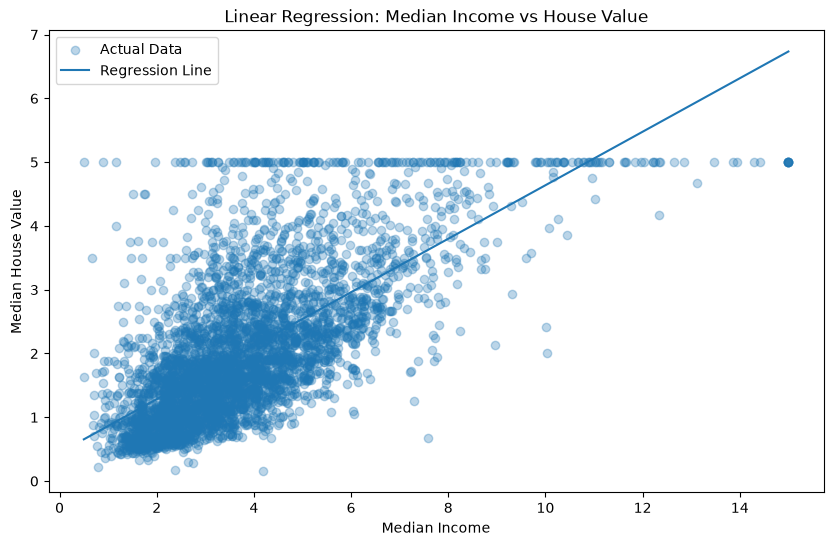

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Sort X values so the regression line is drawn correctly
sort_index = np.argsort(X_test["MedInc"].to_numpy())

X_test_sorted = X_test["MedInc"].to_numpy()[sort_index]
y_pred_sorted = y_pred_test[sort_index]

plt.figure(figsize=(10, 6))

# Actual observations
plt.scatter(
    X_test["MedInc"],
    y_test,
    alpha=0.3,
    label="Actual Data"
)

# Model predictions
plt.plot(
    X_test_sorted,
    y_pred_sorted,
    label="Regression Line"
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression: Median Income vs House Value")

plt.legend()
plt.show()

## Scikit-learn Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

## Evaluate the sklearn model

In [15]:
sklearn_mae = mean_absolute_error(y_test, y_pred_sklearn)

sklearn_mse = mean_squared_error(y_test, y_pred_sklearn)
sklearn_rmse = np.sqrt(sklearn_mse)

sklearn_r2 = r2_score(y_test, y_pred_sklearn)

print("Scikit-learn Results")
print("MAE:", sklearn_mae)
print("RMSE:", sklearn_rmse)
print("R²:", sklearn_r2)

Scikit-learn Results
MAE: 0.629908653009376
RMSE: 0.8420901241414454
R²: 0.45885918903846656


## Compare

In [16]:
print("FROM-SCRATCH MODEL")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

print("\nSCIKIT-LEARN MODEL")
print("MAE :", sklearn_mae)
print("RMSE:", sklearn_rmse)
print("R²  :", sklearn_r2)

FROM-SCRATCH MODEL
MAE : 0.6299086523840834
RMSE: 0.8420901241376189
R²  : 0.4588591890433845

SCIKIT-LEARN MODEL
MAE : 0.629908653009376
RMSE: 0.8420901241414454
R²  : 0.45885918903846656


## Also compare the learned parameters

In [17]:
print("FROM SCRATCH")
print("theta_0:", theta_0)
print("theta_1:", theta_1)

print("\nSCIKIT-LEARN")
print("Intercept:", sklearn_model.intercept_)
print("Coefficient:", sklearn_model.coef_[0])

FROM SCRATCH
theta_0: 2.071946933891858
theta_1: 0.7985195630821527

SCIKIT-LEARN
Intercept: 2.071946937378876
Coefficient: 0.7985195644260356


## Create a comparison table
Instead of printing the metrics separately, we will put them into a Pandas table.

In [18]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["From Scratch", "Scikit-learn"],
    "MAE": [mae, sklearn_mae],
    "RMSE": [rmse, sklearn_rmse],
    "R²": [r2, sklearn_r2]
})

comparison

,Model,MAE,RMSE,R²
0,From Scratch,0.629909,0.84209,0.458859
1,Scikit-learn,0.629909,0.84209,0.458859


### Model Comparison

The from-scratch linear regression model and the Scikit-learn
LinearRegression model produced similar evaluation results.

The from-scratch model was trained using gradient descent, while
Scikit-learn provides a built-in implementation of linear regression.

The comparison shows that the manually implemented model is able to
learn a similar linear relationship between median income and median
house value.

## Save our experiment results
Now we will save our results to experiments/results.csv

In [19]:
comparison.to_csv(
    "../experiments/results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
